### Importación de datos



In [ ]:
import pandas as pd
from pathlib import Path

base_path = Path('base-de-datos-challenge1-latam')
archivos_tiendas = sorted(base_path.glob('tienda_*.csv'))

# Carga robusta: soporta nombres con espacios accidentales
tiendas = [pd.read_csv(archivo) for archivo in archivos_tiendas]

# Alias por compatibilidad con el resto del notebook
tienda, tienda2, tienda3, tienda4 = tiendas

print('Archivos cargados:')
for archivo in archivos_tiendas:
    print('-', archivo.name)

print('\nColumnas disponibles:')
print(tienda.columns.tolist())

tienda.head()

Archivos cargados:
- tienda_1 .csv
- tienda_2.csv
- tienda_3.csv
- tienda_4.csv

Columnas disponibles:
['Producto', 'Categoría del Producto', 'Precio', 'Costo de envío', 'Fecha de Compra', 'Vendedor', 'Lugar de Compra', 'Calificación', 'Método de pago', 'Cantidad de cuotas', 'lat', 'lon']


,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [3]:
import matplotlib.pyplot as plt

nombres_tiendas = [f'Tienda {i}' for i in range(1, 5)]

facturacion = {
    nombre: df['Precio'].sum()
    for nombre, df in zip(nombres_tiendas, tiendas)
}

facturacion_df = (
    pd.Series(facturacion, name='Facturación total')
    .sort_values(ascending=False)
    .to_frame()
)

facturacion_df

Matplotlib is building the font cache; this may take a moment.


,Facturación total
Tienda 1,1.150880e+09
Tienda 2,1.116344e+09
Tienda 3,1.098020e+09
Tienda 4,1.038376e+09


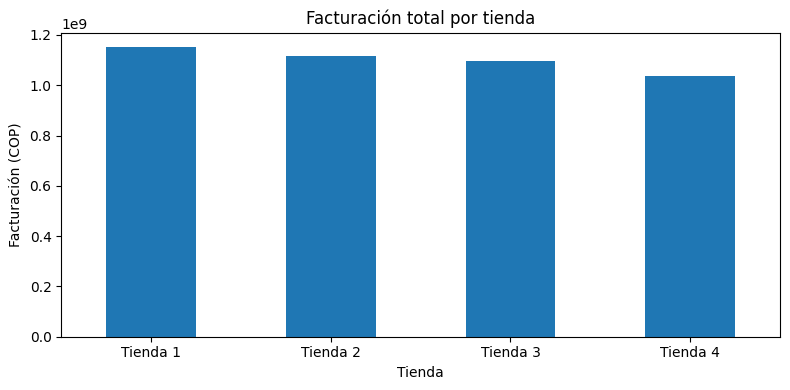

Mayor facturación: Tienda 1
Menor facturación: Tienda 4


In [4]:
ax = facturacion_df.plot(
    kind='bar',
    legend=False,
    figsize=(8, 4),
    color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
)
ax.set_title('Facturación total por tienda')
ax.set_xlabel('Tienda')
ax.set_ylabel('Facturación (COP)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('Mayor facturación:', facturacion_df.index[0])
print('Menor facturación:', facturacion_df.index[-1])

# 2. Ventas por categoría

In [5]:
ventas_categoria = []

for nombre, df in zip(nombres_tiendas, tiendas):
    conteo = (
        df['Categoría del Producto']
        .value_counts()
        .rename(nombre)
    )
    ventas_categoria.append(conteo)

ventas_categoria_df = pd.concat(ventas_categoria, axis=1).fillna(0).astype(int)
ventas_categoria_df['Total'] = ventas_categoria_df.sum(axis=1)
ventas_categoria_df = ventas_categoria_df.sort_values('Total', ascending=False)

ventas_categoria_df.head(10)

,Tienda 1,Tienda 2,Tienda 3,Tienda 4,Total
Categoría del Producto,,,,,
Muebles,465,442,499,480,1886
Electrónicos,448,422,451,451,1772
Juguetes,324,313,315,338,1290
Electrodomésticos,312,305,278,254,1149
Deportes y diversión,284,275,277,277,1113
Instrumentos musicales,182,224,177,170,753
Libros,173,197,185,187,742
Artículos para el hogar,171,181,177,201,730


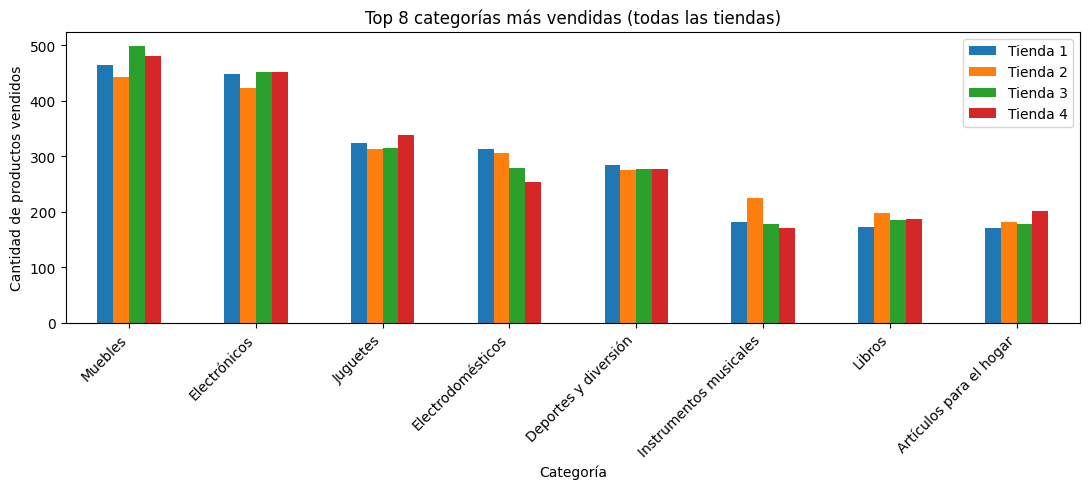

Categoría más vendida en el consolidado: Muebles


In [6]:
ax = ventas_categoria_df[nombres_tiendas].head(8).plot(
    kind='bar',
    figsize=(11, 5)
)
ax.set_title('Top 8 categorías más vendidas (todas las tiendas)')
ax.set_xlabel('Categoría')
ax.set_ylabel('Cantidad de productos vendidos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

categoria_top = ventas_categoria_df.index[0]
print('Categoría más vendida en el consolidado:', categoria_top)

# 3. Calificación promedio de la tienda


In [7]:
calificacion_promedio = {
    nombre: df['Calificación'].mean()
    for nombre, df in zip(nombres_tiendas, tiendas)
}

calificacion_df = (
    pd.Series(calificacion_promedio, name='Calificación promedio')
    .sort_values(ascending=False)
    .to_frame()
)

calificacion_df

,Calificación promedio
Tienda 3,4.048326
Tienda 2,4.037304
Tienda 4,3.995759
Tienda 1,3.976685


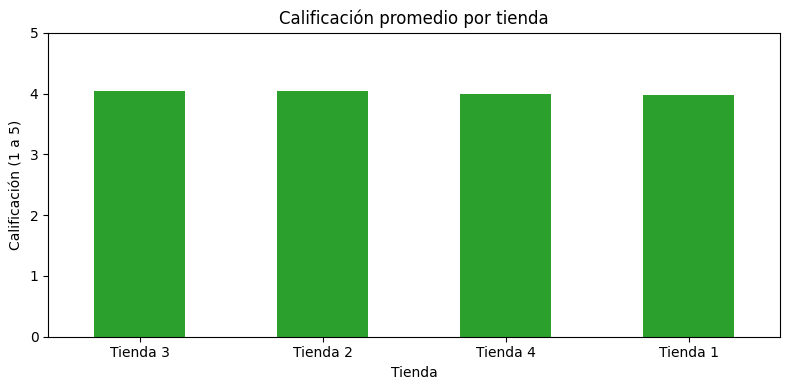

Mejor calificación promedio: Tienda 3
Peor calificación promedio: Tienda 1


In [8]:
ax = calificacion_df.plot(
    kind='bar',
    legend=False,
    figsize=(8, 4),
    color='#2ca02c'
)
ax.set_title('Calificación promedio por tienda')
ax.set_xlabel('Tienda')
ax.set_ylabel('Calificación (1 a 5)')
ax.set_ylim(0, 5)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('Mejor calificación promedio:', calificacion_df.index[0])
print('Peor calificación promedio:', calificacion_df.index[-1])

# 4. Productos más y menos vendidos

In [9]:
top_bottom_productos = {}

for nombre, df in zip(nombres_tiendas, tiendas):
    conteo_producto = df['Producto'].value_counts()
    top_bottom_productos[nombre] = {
        'Mas vendido': conteo_producto.idxmax(),
        'Cantidad mas vendido': conteo_producto.max(),
        'Menos vendido': conteo_producto.idxmin(),
        'Cantidad menos vendido': conteo_producto.min(),
    }

productos_df = pd.DataFrame(top_bottom_productos).T
productos_df

,Mas vendido,Cantidad mas vendido,Menos vendido,Cantidad menos vendido
Tienda 1,Microondas,60,Auriculares con micrófono,33
Tienda 2,Iniciando en programación,65,Juego de mesa,32
Tienda 3,Kit de bancas,57,Bloques de construcción,35
Tienda 4,Cama box,62,Guitarra eléctrica,33


In [10]:
# Muestra simplificada para el informe
productos_df[['Mas vendido', 'Cantidad mas vendido', 'Menos vendido', 'Cantidad menos vendido']]

,Mas vendido,Cantidad mas vendido,Menos vendido,Cantidad menos vendido
Tienda 1,Microondas,60,Auriculares con micrófono,33
Tienda 2,Iniciando en programación,65,Juego de mesa,32
Tienda 3,Kit de bancas,57,Bloques de construcción,35
Tienda 4,Cama box,62,Guitarra eléctrica,33


# 5. Envío promedio por tienda

In [11]:
envio_promedio = {
    nombre: df['Costo de envío'].mean()
    for nombre, df in zip(nombres_tiendas, tiendas)
}

envio_df = (
    pd.Series(envio_promedio, name='Envío promedio')
    .sort_values(ascending=False)
    .to_frame()
)

envio_df

,Envío promedio
Tienda 1,26018.609580
Tienda 2,25216.235693
Tienda 3,24805.680373
Tienda 4,23459.457167


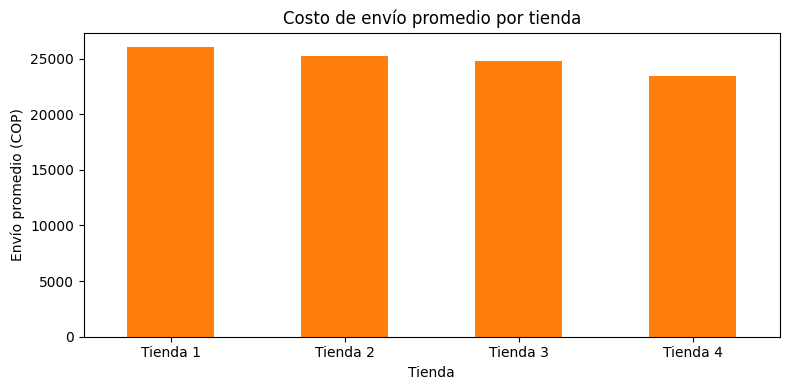

Mayor costo de envío promedio: Tienda 1
Menor costo de envío promedio: Tienda 4


In [12]:
ax = envio_df.plot(
    kind='bar',
    legend=False,
    figsize=(8, 4),
    color='#ff7f0e'
)
ax.set_title('Costo de envío promedio por tienda')
ax.set_xlabel('Tienda')
ax.set_ylabel('Envío promedio (COP)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('Mayor costo de envío promedio:', envio_df.index[0])
print('Menor costo de envío promedio:', envio_df.index[-1])

## Informe final para decisión del Sr. Juan

### Introducción
El objetivo de este análisis fue comparar el desempeño de las 4 tiendas de Alura Store Latam para recomendar **qué tienda debería vender el Sr. Juan**. Para ello, se evaluaron cinco factores clave: facturación total, comportamiento por categorías, calificación promedio de clientes, productos más/menos vendidos y costo de envío promedio.

### Desarrollo

**1) Ingresos totales (facturación)**
- Tienda 1: ~1,150,880,000 COP
- Tienda 2: ~1,116,344,000 COP
- Tienda 3: ~1,098,020,000 COP
- Tienda 4: ~1,038,376,000 COP

Lectura: la Tienda 4 es la de **menor facturación**, con una brecha relevante frente a Tienda 1.

**2) Categorías más y menos vendidas**
- En el consolidado, **Muebles** es la categoría con mayor volumen.
- Las categorías con menor rotación se concentran en la parte baja del ranking consolidado (por ejemplo, segmentos como libros/instrumentos, según la tabla de categorías).

Lectura: no se observa una ventaja competitiva clara de Tienda 4 por mezcla de categorías que compense su menor ingreso.

**3) Calificación promedio de clientes**
- Tienda 3: 4.048
- Tienda 2: 4.037
- Tienda 4: 3.996
- Tienda 1: 3.977

Lectura: Tienda 4 no lidera en satisfacción; queda en posición intermedia, por debajo de Tienda 2 y Tienda 3.

**4) Productos más y menos vendidos**
- Tienda 1: más vendido Microondas (60), menos vendido Auriculares con micrófono (33).
- Tienda 2: más vendido Iniciando en programación (65), menos vendido Juego de mesa (32).
- Tienda 3: más vendido Kit de bancas (57), menos vendido Bloques de construcción (35).
- Tienda 4: más vendido Cama box (62), menos vendido Guitarra eléctrica (33).

Lectura: todas las tiendas tienen productos ganadores y rezagados; en Tienda 4 esto no alcanza para revertir su menor facturación total.

**5) Costo de envío promedio**
- Tienda 1: 26,018.61 COP
- Tienda 2: 25,216.24 COP
- Tienda 3: 24,805.68 COP
- Tienda 4: 23,459.46 COP

Lectura: Tienda 4 sí muestra una fortaleza en eficiencia logística (menor costo promedio de envío).

### Conclusión y recomendación
Con base en el análisis integral, la recomendación es que el Sr. Juan **venda la Tienda 4**.

Justificación objetiva:
- Es la tienda con **menor facturación total**, que es el indicador de mayor impacto financiero.
- No compensa esa desventaja con liderazgo en satisfacción (la mejor calificación la tiene Tienda 3).
- Aunque posee el **menor costo de envío promedio** (fortaleza operativa), este beneficio no logra cerrar la brecha de ingresos frente a las demás tiendas.

En síntesis, al ponderar ingresos, experiencia del cliente y operación, Tienda 4 es la opción más coherente para desinversión.